# 303 — Synthesis figures and summaries for depletion_q uncertainty analysis

This notebook assembles the final `depletion_q` uncertainty workflow into report-ready figures and tables.

It summarizes:

- `300`: baseline re-evaluation validation
- `301a`: individual known-error effects for transmissivity and storage
- `301b`: combined T/S known-error interaction effects
- `302a`: individual probability-weighted uncertainty for transmissivity and storage
- `302b`: joint T/S probability-weighted uncertainty

This notebook does **not** rerun PyCap. It reads completed output tables and creates comparison figures.


## 1. Imports, helper reload, and user controls

In [1]:
from pathlib import Path
import sys
import importlib
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

sys.modules.pop("uncertainty_project_helpers_depletion_q", None)
importlib.invalidate_caches()
import uncertainty_project_helpers_depletion_q as up

print("Helper imported from:", up.__file__)
print("Helper version:", up.HELPER_VERSION)

PROJECT_DIR = up.find_lpr_pycap_opt_dir()
NOTEBOOK_DIR = PROJECT_DIR / "notebooks" / "Uncertainty_Project_depletion_q"
PROJECT_OUTPUT_DIR = NOTEBOOK_DIR / "project_output"

RUN_NAME = "depletion_q_baseline_0.0_1.0_0.01"
OUTPUT_DIR = PROJECT_OUTPUT_DIR / "303_uncertainty_report_figures_depletion_q" / "full_synthesis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PARAMETERS = ["transmissivity", "storage"]
PARAMETER_LABELS = {"transmissivity": "Transmissivity", "storage": "Storage"}

up.apply_plot_style()

print("PROJECT_DIR:", PROJECT_DIR)
print("PROJECT_OUTPUT_DIR:", PROJECT_OUTPUT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


Helper imported from: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/uncertainty_project_helpers_depletion_q.py
Helper version: 2026-05-24_depletion_q_304_v7_full_uncertainty_annotation_higher
PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
PROJECT_OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/303_uncertainty_report_figures_depletion_q/full_synthesis


## 2. Local loading and plotting utilities

In [2]:
def first_existing(paths, label, required=True):
    for path in paths:
        path = Path(path)
        if path.exists():
            return path
    if required:
        searched = "\n".join(str(Path(p)) for p in paths)
        raise FileNotFoundError(f"Could not find {label}. Searched:\n{searched}")
    return None


def load_csv_first(paths, label, required=True):
    path = first_existing(paths, label=label, required=required)
    if path is None:
        return None, None
    return pd.read_csv(path), path


def metric_from_overall(overall_df, metric_name):
    if overall_df is None or overall_df.empty:
        return np.nan
    row = overall_df.loc[overall_df["metric"] == metric_name, "value"]
    return np.nan if row.empty else float(row.iloc[0])


def save_current_fig(fig, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return path


def archive_baseline_front():
    context = up.load_depletion_q_context(RUN_NAME, project_dir=PROJECT_DIR)
    archive = up.read_pareto_archive_summary(RUN_NAME, context.run_dir)
    front = up.select_final_feasible_front1(archive).copy()
    front["pumping_objective_cfs"] = front["obj_well"].astype(float) * up.GPM2CFS
    front["depletion_cfs"] = front[up.DEPLETION_OBS_NAME].astype(float)
    front["streamflow_cfs"] = up.HISTORIC_STREAMFLOW_CFS - front["depletion_cfs"]
    return front.sort_values("pumping_objective_cfs")


def plot_original_vs_parameter_reevaluation(original_front, known_long, parameter, outfile, y_metric="streamflow"):
    label = PARAMETER_LABELS.get(parameter, parameter)
    ycol = "streamflow_cfs" if y_metric == "streamflow" else "depletion_cfs"
    ylabel = "Streamflow = 8.6 cfs - depletion (cfs)" if y_metric == "streamflow" else "Depletion (cfs)"
    fig, ax = plt.subplots(figsize=(9.2, 6.0))

    ax.plot(
        original_front["pumping_objective_cfs"],
        original_front[ycol],
        color="#8FC3DA",
        linewidth=2.6,
        label="Original baseline optimized front",
    )

    df = up.sort_for_plot(known_long, xcol=up.PUMPING_COLUMN_FOR_HYDRO_PLOTS)
    for scenario in list(df["scenario"].dropna().unique()):
        g = df.loc[df["scenario"] == scenario].copy()
        if g.empty:
            continue
        if str(scenario).startswith("baseline"):
            color = "#2E86AB"
        elif "minus" in str(scenario) or "T_minus" in str(scenario):
            color = "#2E7D32"
        elif "plus" in str(scenario) or "T_plus" in str(scenario):
            color = "#C62828"
        else:
            color = "#4D4D4D"
        ax.plot(
            g[up.PUMPING_COLUMN_FOR_HYDRO_PLOTS],
            g[ycol],
            marker="o",
            markersize=3,
            linewidth=1.3,
            alpha=0.9,
            color=color,
            label=str(g["scenario"].iloc[0]),
        )

    ax.set_xlabel("Pumping objective: decision-variable pumping (cfs)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Original baseline front vs fixed-design re-evaluation: {label} ({y_metric})")
    ax.legend(loc="best")
    save_current_fig(fig, outfile)


def plot_t_vs_s_known_error_comparison(known_summaries, outfile):
    rows = []
    for parameter, df in known_summaries.items():
        if df is None:
            continue
        for _, row in df.iterrows():
            scenario = str(row["scenario"])
            if scenario.startswith("baseline"):
                continue
            direction = "-10%" if "minus" in scenario or "T_minus" in scenario else "+10%"
            rows.append({
                "parameter": PARAMETER_LABELS.get(parameter, parameter),
                "direction": direction,
                "mean_abs_streamflow_error_cfs": row["mean_absolute_streamflow_error_cfs"],
                "max_abs_streamflow_error_cfs": row["max_absolute_streamflow_error_cfs"],
                "mean_shortfall_cfs": row["mean_streamflow_shortfall_below_baseline_cfs"],
                "mean_streamflow_change_cfs": row["mean_streamflow_change_from_baseline_cfs"],
            })
    comp = pd.DataFrame(rows)
    if comp.empty:
        return comp

    comp.to_csv(OUTPUT_DIR / "303_known_error_T_vs_S_comparison_table.csv", index=False)

    xlabels = [f"{r.parameter}\n{r.direction}" for r in comp.itertuples()]
    x = np.arange(len(comp))

    fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.8))
    axes[0].bar(x, comp["mean_streamflow_change_cfs"])
    axes[0].axhline(0, color="0.35", linestyle="--", linewidth=1)
    axes[0].set_title("A. Signed mean streamflow change")
    axes[0].set_ylabel("Change (cfs)")

    axes[1].bar(x, comp["mean_abs_streamflow_error_cfs"])
    axes[1].set_title("B. Mean absolute streamflow error")
    axes[1].set_ylabel("Absolute error (cfs)")

    axes[2].bar(x, comp["mean_shortfall_cfs"])
    axes[2].set_title("C. Mean streamflow shortfall")
    axes[2].set_ylabel("Shortfall (cfs)")

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels, rotation=35, ha="right")

    fig.suptitle("Known ±10% parameter-error comparison: transmissivity vs storage", y=1.04)
    save_current_fig(fig, outfile)
    return comp


def plot_probability_metric_comparison(prob_overalls, joint_overall, outfile):
    rows = []
    for key, df in prob_overalls.items():
        if df is None:
            continue
        rows.append({
            "analysis": PARAMETER_LABELS.get(key, key),
            "mean_abs_error": metric_from_overall(df, "mean_probability_weighted_absolute_streamflow_error_cfs"),
            "mean_shortfall": metric_from_overall(df, "mean_probability_weighted_streamflow_shortfall_cfs"),
            "mean_std": metric_from_overall(df, "mean_streamflow_std_cfs"),
            "max_abs_error": metric_from_overall(df, "max_probability_weighted_absolute_streamflow_error_cfs"),
        })
    if joint_overall is not None:
        rows.append({
            "analysis": "Joint T/S",
            "mean_abs_error": metric_from_overall(joint_overall, "mean_probability_weighted_absolute_streamflow_error_cfs"),
            "mean_shortfall": metric_from_overall(joint_overall, "mean_probability_weighted_streamflow_shortfall_cfs"),
            "mean_std": metric_from_overall(joint_overall, "mean_streamflow_std_cfs"),
            "max_abs_error": metric_from_overall(joint_overall, "max_probability_weighted_absolute_streamflow_error_cfs"),
        })

    comp = pd.DataFrame(rows)
    if comp.empty:
        return comp

    comp.to_csv(OUTPUT_DIR / "303_probability_weighted_uncertainty_comparison_table.csv", index=False)

    x = np.arange(len(comp))
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8))

    axes[0].bar(x, comp["mean_abs_error"])
    axes[0].set_title("A. Mean abs. streamflow error")
    axes[0].set_ylabel("cfs")

    axes[1].bar(x, comp["mean_shortfall"])
    axes[1].set_title("B. Mean streamflow shortfall")
    axes[1].set_ylabel("cfs")

    axes[2].bar(x, comp["mean_std"])
    axes[2].set_title("C. Mean streamflow standard deviation")
    axes[2].set_ylabel("cfs")

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(comp["analysis"], rotation=25, ha="right")

    fig.suptitle("Probability-weighted uncertainty comparison", y=1.04)
    save_current_fig(fig, outfile)
    return comp


## 3. Load output tables from 301a, 301b, 302a, and 302b

In [3]:
known_long = {}
known_summary = {}
prob_member = {}
prob_overall = {}

for parameter in PARAMETERS:
    # 301a primary path, with fallback to older 301 path if needed.
    known_dir_primary = PROJECT_OUTPUT_DIR / "301a_individual_parameter_known_error_depletion_q" / parameter
    known_dir_legacy = PROJECT_OUTPUT_DIR / "301_known_parameter_error_depletion_q" / parameter

    known_long[parameter], path = load_csv_first(
        [
            known_dir_primary / f"301a_{parameter}_scenario_reevaluation_long.csv",
            known_dir_legacy / f"301_{parameter}_scenario_reevaluation_long.csv",
        ],
        label=f"301a long output for {parameter}",
        required=True,
    )
    print(f"Loaded 301a long for {parameter}:", path)

    known_summary[parameter], path = load_csv_first(
        [
            known_dir_primary / f"301a_{parameter}_scenario_summary.csv",
            known_dir_legacy / f"301_{parameter}_scenario_summary.csv",
        ],
        label=f"301a summary output for {parameter}",
        required=True,
    )
    print(f"Loaded 301a summary for {parameter}:", path)

    # 302a primary path, with fallback to older 302 path if needed.
    prob_dir_primary = PROJECT_OUTPUT_DIR / "302a_probability_weighted_individual_parameter_uncertainty_depletion_q" / parameter
    prob_dir_legacy = PROJECT_OUTPUT_DIR / "302_probability_weighted_parameter_uncertainty_depletion_q" / parameter

    prob_member[parameter], path = load_csv_first(
        [
            prob_dir_primary / f"302a_{parameter}_probability_weighted_member_summary.csv",
            prob_dir_legacy / f"302_{parameter}_probability_weighted_member_summary.csv",
        ],
        label=f"302a member summary for {parameter}",
        required=True,
    )
    print(f"Loaded 302a member summary for {parameter}:", path)

    prob_overall[parameter], path = load_csv_first(
        [
            prob_dir_primary / f"302a_{parameter}_probability_weighted_overall_summary.csv",
            prob_dir_legacy / f"302_{parameter}_probability_weighted_overall_summary.csv",
        ],
        label=f"302a overall summary for {parameter}",
        required=True,
    )
    print(f"Loaded 302a overall summary for {parameter}:", path)

# 301b combined known-error interaction outputs.
dir_301b = PROJECT_OUTPUT_DIR / "301b_combined_T_storage_known_error_depletion_q"
combined_known_long, combined_known_long_path = load_csv_first(
    [dir_301b / "301b_combined_T_storage_reevaluation_long.csv"],
    label="301b combined T/S long output",
    required=True,
)
combined_interaction, combined_interaction_path = load_csv_first(
    [dir_301b / "301b_combined_T_storage_interaction_summary.csv"],
    label="301b combined T/S interaction summary",
    required=True,
)
print("Loaded 301b long:", combined_known_long_path)
print("Loaded 301b interaction summary:", combined_interaction_path)

# 302b joint probability outputs.
dir_302b = PROJECT_OUTPUT_DIR / "302b_joint_T_storage_probability_weighted_uncertainty_depletion_q"
joint_probability, joint_probability_path = load_csv_first(
    [dir_302b / "302b_joint_T_storage_probability_grid.csv"],
    label="302b joint probability grid",
    required=True,
)
joint_member, joint_member_path = load_csv_first(
    [dir_302b / "302b_joint_T_storage_probability_weighted_member_summary.csv"],
    label="302b joint member summary",
    required=True,
)
joint_overall, joint_overall_path = load_csv_first(
    [dir_302b / "302b_joint_T_storage_probability_weighted_overall_summary.csv"],
    label="302b joint overall summary",
    required=True,
)
joint_grid, joint_grid_path = load_csv_first(
    [dir_302b / "302b_joint_T_storage_grid_scenario_summary.csv"],
    label="302b joint grid scenario summary",
    required=True,
)
print("Loaded 302b joint grid:", joint_grid_path)
print("Loaded 302b joint overall:", joint_overall_path)

display(known_summary["transmissivity"])
display(known_summary["storage"])
display(joint_overall)


Loaded 301a long for transmissivity: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301a_individual_parameter_known_error_depletion_q/transmissivity/301a_transmissivity_scenario_reevaluation_long.csv
Loaded 301a summary for transmissivity: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301a_individual_parameter_known_error_depletion_q/transmissivity/301a_transmissivity_scenario_summary.csv
Loaded 302a member summary for transmissivity: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302a_probability_weighted_individual_parameter_uncertainty_depletion_q/transmissivity/302a_transmissivity_probability_weighted_member_summary.csv
Loaded 302a overall summary for transmissivity: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302a_probability_weighted_individual_parameter_uncertainty_depletion_q/transmissivity/30

,scenario,parameter_name,parameter_label,parameter_symbol,parameter_factor,parameter_value,base_parameter_value,T_factor,T_value,S_factor,...,min_streamflow_cfs,max_streamflow_cfs,mean_depletion_change_from_baseline_cfs,mean_streamflow_change_from_baseline_cfs,mean_absolute_depletion_error_cfs,max_absolute_depletion_error_cfs,mean_absolute_streamflow_error_cfs,max_absolute_streamflow_error_cfs,mean_streamflow_shortfall_below_baseline_cfs,max_streamflow_shortfall_below_baseline_cfs
0,T_minus_10pct,NaN,NaN,NaN,NaN,NaN,NaN,0.9,1530.0,NaN,...,4.071497,7.863171,-0.176498,0.176498,0.176498,0.254079,0.176498,0.254079,0.000000,0.000000
1,baseline_T,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1700.0,NaN,...,3.817418,7.788917,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,T_plus_10pct,NaN,NaN,NaN,NaN,NaN,NaN,1.1,1870.0,NaN,...,3.581795,7.717510,0.166142,-0.166142,0.166142,0.235623,0.166142,0.235623,0.166142,0.235623


,scenario,parameter_name,parameter_label,parameter_symbol,parameter_factor,parameter_value,base_parameter_value,T_factor,T_value,S_factor,...,min_streamflow_cfs,max_streamflow_cfs,mean_depletion_change_from_baseline_cfs,mean_streamflow_change_from_baseline_cfs,mean_absolute_depletion_error_cfs,max_absolute_depletion_error_cfs,mean_absolute_streamflow_error_cfs,max_absolute_streamflow_error_cfs,mean_streamflow_shortfall_below_baseline_cfs,max_streamflow_shortfall_below_baseline_cfs
0,storage_minus_10pct,storage,Storage,S,0.9,0.108,0.12,NaN,NaN,0.9,...,3.556684,7.709747,0.184014,-0.184014,0.184014,0.260734,0.184014,0.260734,0.184014,0.260734
1,baseline_storage,storage,Storage,S,1.0,0.120,0.12,NaN,NaN,1.0,...,3.817418,7.788917,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,storage_plus_10pct,storage,Storage,S,1.1,0.132,0.12,NaN,NaN,1.1,...,4.047547,7.856300,-0.159990,0.159990,0.159990,0.230130,0.159990,0.230130,0.000000,0.000000


,metric,value
0,n_members,296.000000
1,mean_expected_streamflow_bias_cfs,-0.006372
2,mean_expected_depletion_bias_cfs,0.006372
3,mean_probability_weighted_absolute_streamflow_error_cfs,0.179871
4,max_probability_weighted_absolute_streamflow_error_cfs,0.256745
5,mean_probability_weighted_absolute_depletion_error_cfs,0.179871
6,max_probability_weighted_absolute_depletion_error_cfs,0.256745
7,mean_probability_weighted_streamflow_shortfall_cfs,0.093121
8,max_probability_weighted_streamflow_shortfall_cfs,0.131202
9,mean_probability_of_streamflow_shortfall,0.356345


## 4. Original baseline front vs fixed-design re-evaluation curves

These figures compare the original optimized baseline Pareto front against the fixed-design re-evaluation curves under transmissivity and storage perturbations.


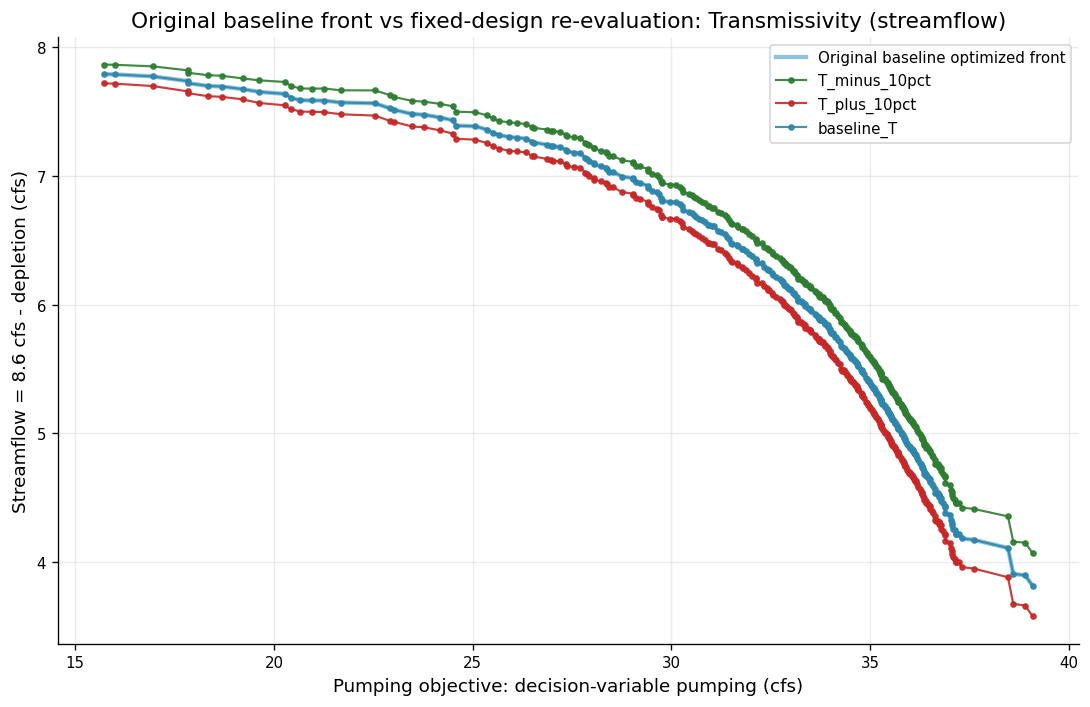

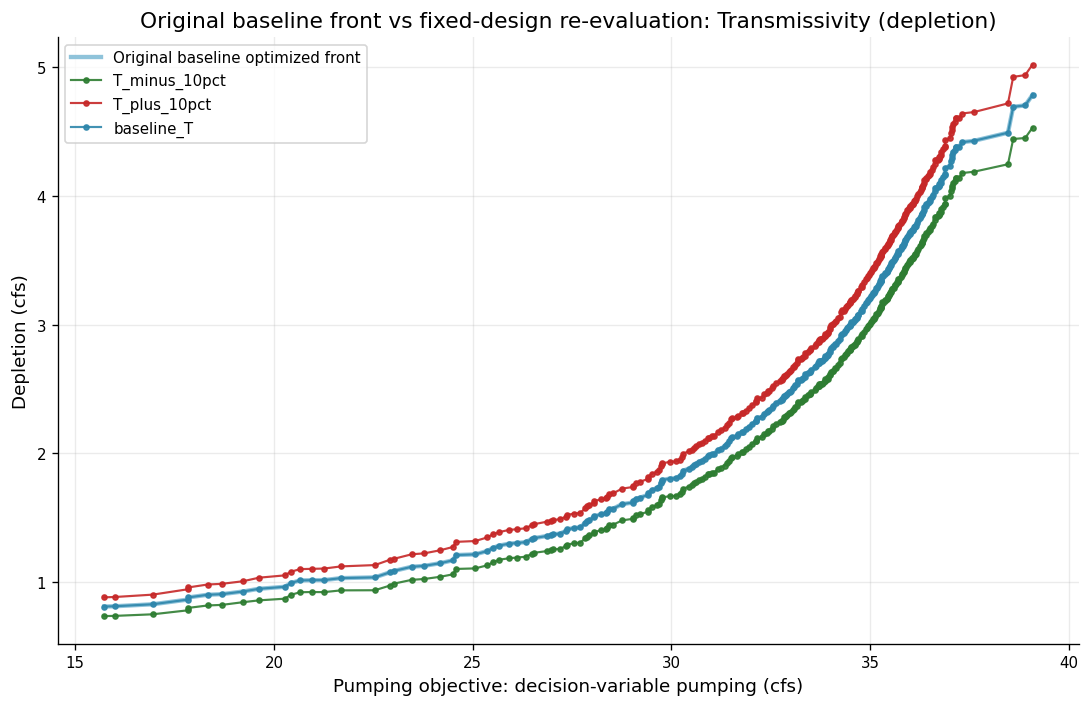

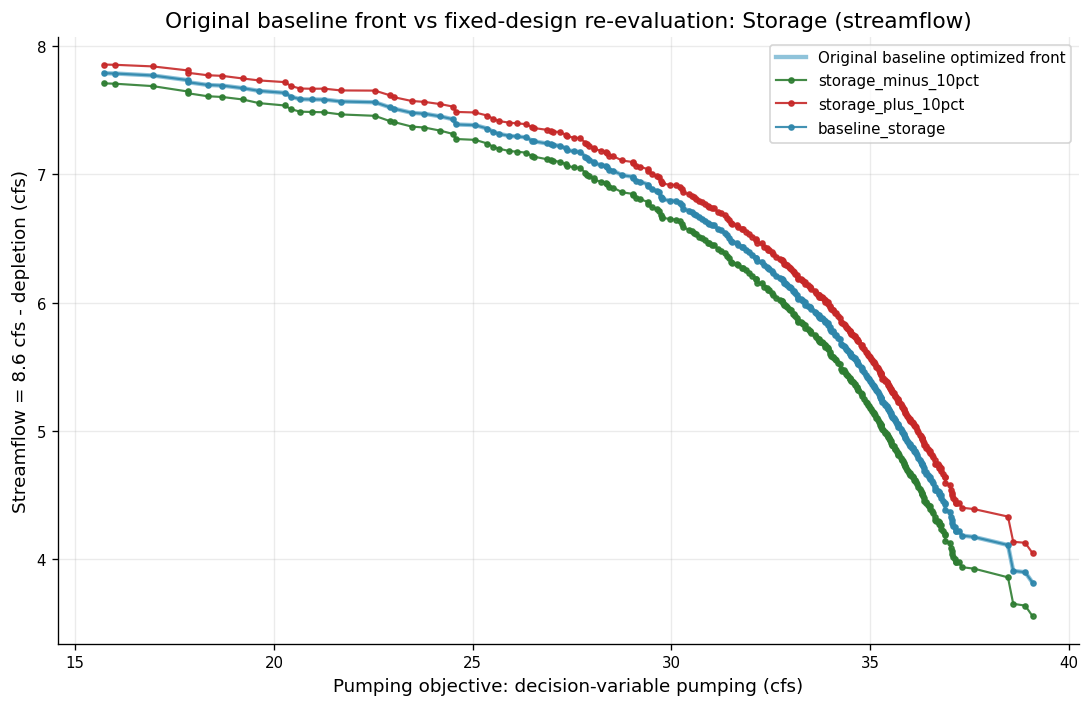

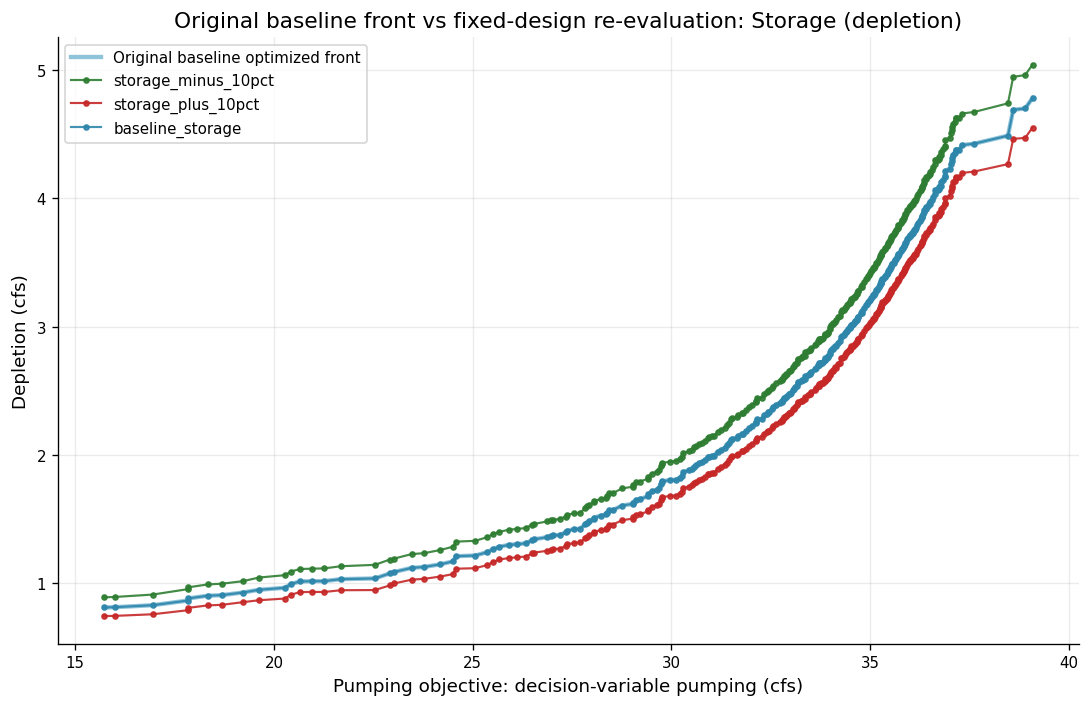

In [4]:
original_front = archive_baseline_front()

for parameter in PARAMETERS:
    plot_original_vs_parameter_reevaluation(
        original_front=original_front,
        known_long=known_long[parameter],
        parameter=parameter,
        outfile=OUTPUT_DIR / f"303_original_baseline_front_vs_{parameter}_reevaluation_streamflow.png",
        y_metric="streamflow",
    )
    plot_original_vs_parameter_reevaluation(
        original_front=original_front,
        known_long=known_long[parameter],
        parameter=parameter,
        outfile=OUTPUT_DIR / f"303_original_baseline_front_vs_{parameter}_reevaluation_depletion.png",
        y_metric="depletion",
    )


## 5. Transmissivity vs storage known-error comparison

This figure compares the magnitude and direction of the individual ±10% known-error effects.


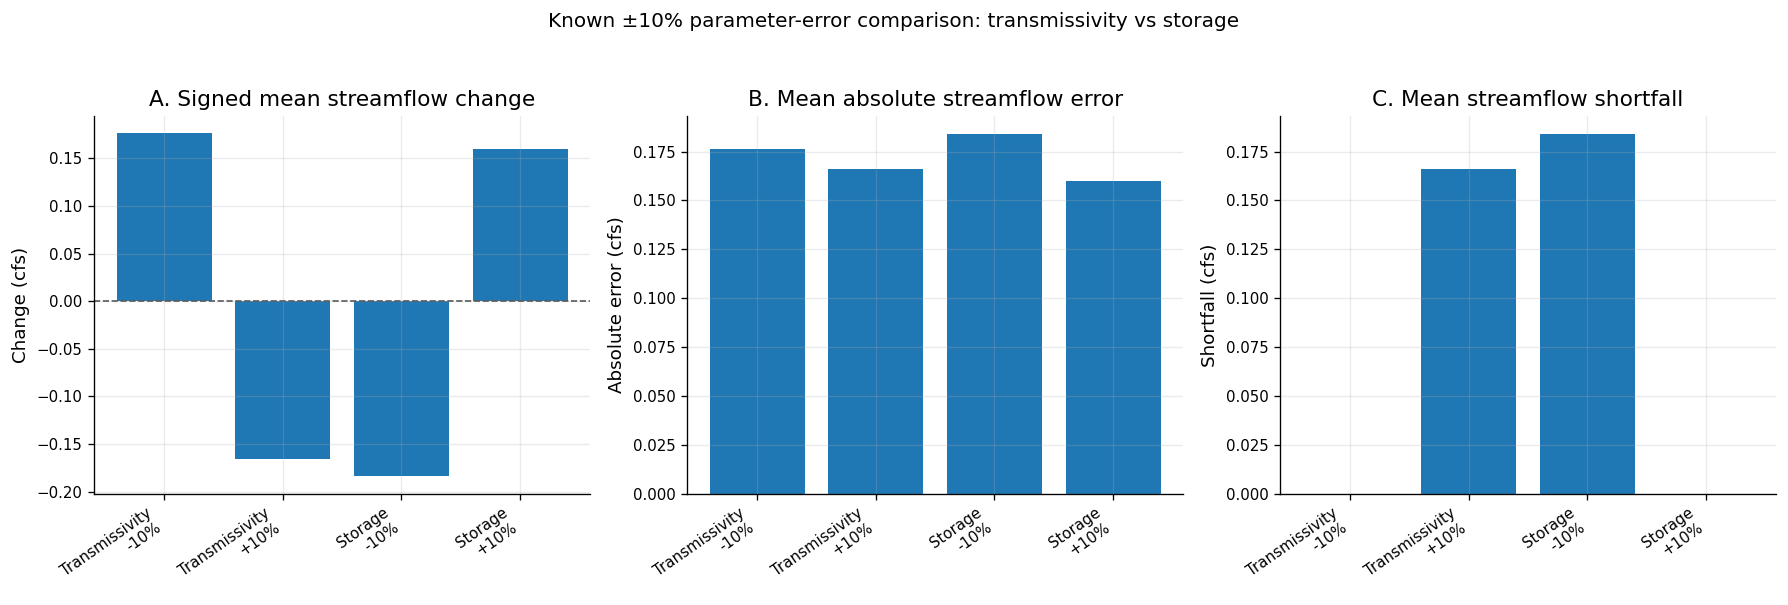

,parameter,direction,mean_abs_streamflow_error_cfs,max_abs_streamflow_error_cfs,mean_shortfall_cfs,mean_streamflow_change_cfs
0,Transmissivity,-10%,0.176498,0.254079,0.000000,0.176498
1,Transmissivity,+10%,0.166142,0.235623,0.166142,-0.166142
2,Storage,-10%,0.184014,0.260734,0.184014,-0.184014
3,Storage,+10%,0.159990,0.230130,0.000000,0.159990


In [5]:
known_effect_comparison = plot_t_vs_s_known_error_comparison(
    known_summaries=known_summary,
    outfile=OUTPUT_DIR / "303_T_vs_S_known_error_comparison_1x3.png",
)
display(known_effect_comparison)


## 6. Combined T/S known-error interaction figures

These figures summarize the 301b result: same-direction T/S changes mostly cancel, while opposing T/S changes amplify.


In [6]:
# Copy key 301b figures into the 303 synthesis folder when available.
copy_pairs = [
    (dir_301b / "301b_combined_T_storage_pumping_vs_streamflow.png", OUTPUT_DIR / "303_301b_combined_T_storage_pumping_vs_streamflow.png"),
    (dir_301b / "301b_streamflow_interaction_effect_vs_pumping.png", OUTPUT_DIR / "303_301b_streamflow_interaction_effect_vs_pumping.png"),
    (dir_301b / "301b_combined_T_storage_mean_effects_and_interactions.png", OUTPUT_DIR / "303_301b_combined_T_storage_mean_effects_and_interactions.png"),
]
for src, dst in copy_pairs:
    if src.exists():
        shutil.copy2(src, dst)
        print("Copied:", dst)
    else:
        print("Skipped missing figure:", src)

display(combined_interaction)


Copied: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/303_uncertainty_report_figures_depletion_q/full_synthesis/303_301b_combined_T_storage_pumping_vs_streamflow.png
Copied: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/303_uncertainty_report_figures_depletion_q/full_synthesis/303_301b_streamflow_interaction_effect_vs_pumping.png
Copied: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/303_uncertainty_report_figures_depletion_q/full_synthesis/303_301b_combined_T_storage_mean_effects_and_interactions.png


,scenario,scenario_label,T_factor,S_factor,n_members,mean_combined_streamflow_change_cfs,mean_additive_expected_streamflow_change_cfs,mean_streamflow_interaction_effect_cfs,mean_abs_streamflow_interaction_effect_cfs,max_abs_streamflow_interaction_effect_cfs,mean_combined_depletion_change_cfs,mean_additive_expected_depletion_change_cfs,mean_depletion_interaction_effect_cfs,mean_abs_depletion_interaction_effect_cfs,max_abs_depletion_interaction_effect_cfs
0,Thigh_Shigh,"T +10%, S +10%",1.1,1.1,296,-2.415485e-16,-0.006152,0.006152,0.006152,0.007390,2.306713e-16,0.006152,-0.006152,0.006152,0.007390
1,Thigh_Slow,"T +10%, S -10%",1.1,0.9,296,-3.567895e-01,-0.350156,-0.006633,0.006633,0.007904,3.567895e-01,0.350156,0.006633,0.006633,0.007904
2,Tlow_Shigh,"T -10%, S +10%",0.9,1.1,296,3.295709e-01,0.336489,-0.006918,0.006918,0.008304,-3.295709e-01,-0.336489,0.006918,0.006918,0.008304
3,Tlow_Slow,"T -10%, S -10%",0.9,0.9,296,-1.800362e-16,-0.007516,0.007516,0.007516,0.009030,1.819115e-16,0.007516,-0.007516,0.007516,0.009030
4,baseline_T1_S1,"Baseline T, baseline S",1.0,1.0,296,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000


## 7. Probability-weighted uncertainty comparison: T-only, S-only, and joint T/S

This figure compares expected uncertainty cost from individual-parameter uncertainty and joint T/S uncertainty.


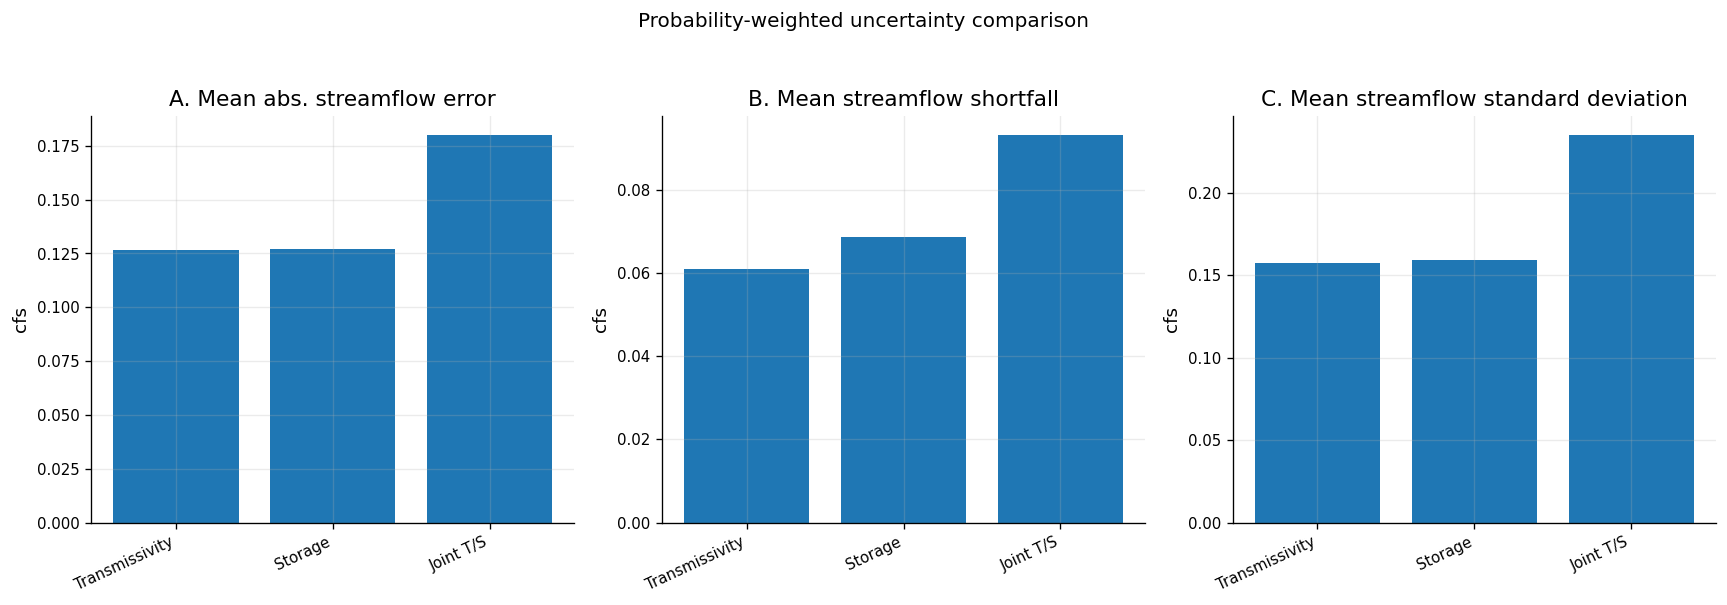

,analysis,mean_abs_error,mean_shortfall,mean_std,max_abs_error
0,Transmissivity,0.126483,0.061058,0.157468,0.180805
1,Storage,0.127274,0.068723,0.159180,0.181505
2,Joint T/S,0.179871,0.093121,0.235015,0.256745


In [7]:
probability_comparison = plot_probability_metric_comparison(
    prob_overalls=prob_overall,
    joint_overall=joint_overall,
    outfile=OUTPUT_DIR / "303_probability_weighted_T_S_joint_comparison_1x3.png",
)
display(probability_comparison)


## 8. Joint T/S probability-weighted figures and robust-decision views

This section copies key diagnostic figures from the joint probability notebook (`302b`) and, when available, also copies the main decision-oriented uncertainty figures from `304`.

The current `304` workflow now emphasizes:

- the global streamflow uncertainty structure
- the local full streamflow uncertainty plot
- threshold-based shortfall probability
- expected shortfall magnitude
- robust pumping by threshold and reliability


Copied: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/303_uncertainty_report_figures_depletion_q/full_synthesis/303_302b_joint_T_storage_probability_heatmap.png
Copied: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/303_uncertainty_report_figures_depletion_q/full_synthesis/303_302b_joint_T_storage_mean_streamflow_change_heatmap.png
Copied: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/303_uncertainty_report_figures_depletion_q/full_synthesis/303_302b_joint_T_storage_mean_abs_streamflow_change_heatmap.png
Copied: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/303_uncertainty_report_figures_depletion_q/full_synthesis/303_302b_joint_T_storage_diffusivity_vs_mean_streamflow_change.png
Copied: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/303_uncertainty_report_

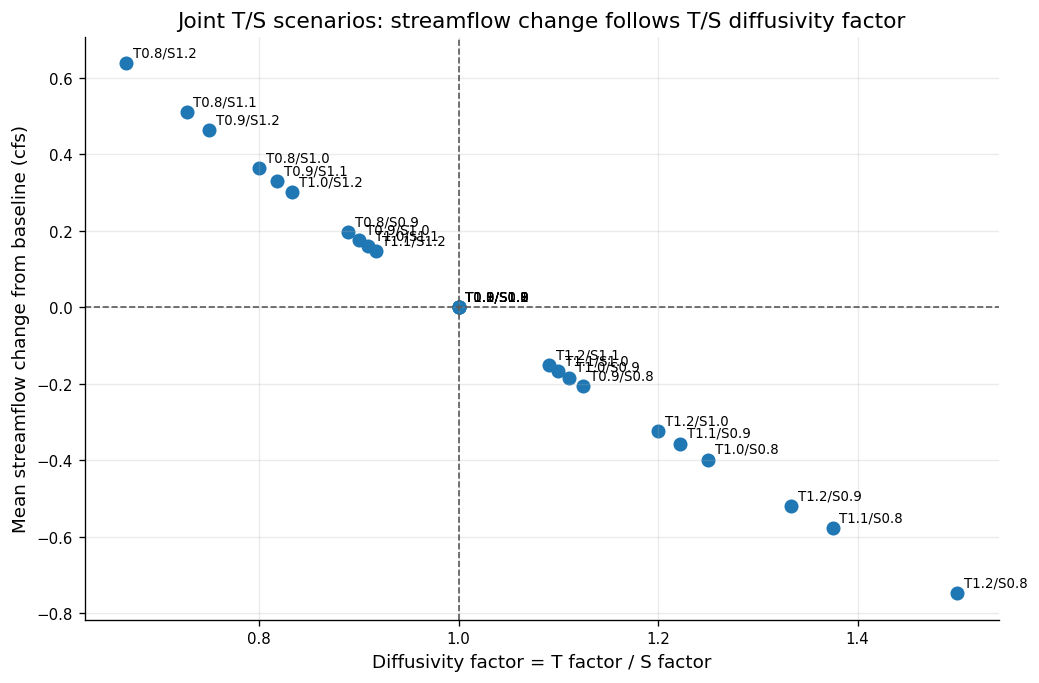

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/303_uncertainty_report_figures_depletion_q/full_synthesis/303_joint_diffusivity_vs_mean_streamflow_change_recreated.png
Copied 304 figure into synthesis folder: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/303_uncertainty_report_figures_depletion_q/full_synthesis/303_304_full_streamflow_uncertainty_structure_vs_pumping.png
304 figure not found yet (run 304 first if you want it in 303): /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/304_robust_decision_analysis_depletion_q/304_vertical_uncertainty_envelope_height_vs_pumping.png
Copied 304 figure into synthesis folder: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/303_uncertainty_report_figures_depletion_q/full_synthesis/303_304_local_full_streamflow_uncertainty.png
304 figure not found yet (ru

In [8]:
copy_pairs = [
    (dir_302b / "302b_joint_T_storage_probability_heatmap.png", OUTPUT_DIR / "303_302b_joint_T_storage_probability_heatmap.png"),
    (dir_302b / "302b_joint_T_storage_mean_streamflow_change_heatmap.png", OUTPUT_DIR / "303_302b_joint_T_storage_mean_streamflow_change_heatmap.png"),
    (dir_302b / "302b_joint_T_storage_mean_abs_streamflow_change_heatmap.png", OUTPUT_DIR / "303_302b_joint_T_storage_mean_abs_streamflow_change_heatmap.png"),
    (dir_302b / "302b_joint_T_storage_diffusivity_vs_mean_streamflow_change.png", OUTPUT_DIR / "303_302b_joint_T_storage_diffusivity_vs_mean_streamflow_change.png"),
    (dir_302b / "302b_joint_T_storage_streamflow_uncertainty_dashboard.png", OUTPUT_DIR / "303_302b_joint_T_storage_streamflow_uncertainty_dashboard.png"),
    (dir_302b / "302b_joint_T_storage_probability_weighted_streamflow_shortfall.png", OUTPUT_DIR / "303_302b_joint_T_storage_probability_weighted_streamflow_shortfall.png"),
    (dir_302b / "302b_joint_T_storage_streamflow_standard_deviation.png", OUTPUT_DIR / "303_302b_joint_T_storage_streamflow_standard_deviation.png"),
    (dir_302b / "302b_joint_T_storage_probability_of_streamflow_shortfall.png", OUTPUT_DIR / "303_302b_joint_T_storage_probability_of_streamflow_shortfall.png"),
]
for src, dst in copy_pairs:
    if src.exists():
        shutil.copy2(src, dst)
        print("Copied:", dst)
    else:
        print("Skipped missing figure:", src)

# Recreate the diffusivity plot in case 302b has just been rerun with updated summaries.
up.plot_joint_diffusivity_vs_streamflow_change(
    grid_summary=joint_grid,
    outfile=OUTPUT_DIR / "303_joint_diffusivity_vs_mean_streamflow_change_recreated.png",
)

# Also copy main 304 decision-oriented uncertainty figures when 304 has been run.
dir_304 = PROJECT_OUTPUT_DIR / "304_robust_decision_analysis_depletion_q"
copy_pairs_304 = [
    (dir_304 / "304_full_streamflow_uncertainty_structure_vs_pumping.png", OUTPUT_DIR / "303_304_full_streamflow_uncertainty_structure_vs_pumping.png"),
    (dir_304 / "304_vertical_uncertainty_envelope_height_vs_pumping.png", OUTPUT_DIR / "303_304_vertical_uncertainty_envelope_height_vs_pumping.png"),
    (dir_304 / "304_local_full_streamflow_uncertainty.png", OUTPUT_DIR / "303_304_local_full_streamflow_uncertainty.png"),
    (dir_304 / "304_local_upper_lower_boundary_interpretation.png", OUTPUT_DIR / "303_304_local_upper_lower_boundary_interpretation.png"),
    (dir_304 / "304_local_streamflow_uncertainty_relationship_1x2.png", OUTPUT_DIR / "303_304_local_streamflow_uncertainty_relationship_1x2.png"),
    (dir_304 / "304_probability_below_streamflow_thresholds_vs_pumping.png", OUTPUT_DIR / "303_304_probability_below_streamflow_thresholds_vs_pumping.png"),
    (dir_304 / "304_expected_streamflow_shortfall_vs_pumping.png", OUTPUT_DIR / "303_304_expected_streamflow_shortfall_vs_pumping.png"),
    (dir_304 / "304_robust_yield_by_threshold_and_reliability.png", OUTPUT_DIR / "303_304_robust_yield_by_threshold_and_reliability.png"),
    (dir_304 / "304_risk_adjusted_scores_vs_pumping.png", OUTPUT_DIR / "303_304_risk_adjusted_scores_vs_pumping.png"),
]
for src, dst in copy_pairs_304:
    if src.exists():
        shutil.copy2(src, dst)
        print("Copied 304 figure into synthesis folder:", dst)
    else:
        print("304 figure not found yet (run 304 first if you want it in 303):", src)


## 9. Compact synthesis tables

In [9]:
# Known-error compact table.
known_rows = []
for parameter, df in known_summary.items():
    for _, row in df.iterrows():
        known_rows.append({
            "analysis_group": "301a individual known error",
            "parameter": parameter,
            "scenario": row["scenario"],
            "mean_streamflow_change_cfs": row["mean_streamflow_change_from_baseline_cfs"],
            "mean_abs_streamflow_error_cfs": row["mean_absolute_streamflow_error_cfs"],
            "max_abs_streamflow_error_cfs": row["max_absolute_streamflow_error_cfs"],
            "mean_streamflow_shortfall_cfs": row["mean_streamflow_shortfall_below_baseline_cfs"],
        })

known_compact = pd.DataFrame(known_rows)
known_compact.to_csv(OUTPUT_DIR / "303_known_error_compact_synthesis_table.csv", index=False)

# Probability compact table.
probability_comparison.to_csv(OUTPUT_DIR / "303_probability_weighted_compact_synthesis_table.csv", index=False)

# Joint grid compact table sorted from most risky to most protective.
joint_grid_sorted = joint_grid.sort_values("mean_streamflow_change_from_baseline_cfs").copy()
joint_grid_sorted.to_csv(OUTPUT_DIR / "303_joint_T_storage_grid_sorted_by_streamflow_change.csv", index=False)

display(known_compact)
display(probability_comparison)
display(joint_grid_sorted.head())
display(joint_grid_sorted.tail())


,analysis_group,parameter,scenario,mean_streamflow_change_cfs,mean_abs_streamflow_error_cfs,max_abs_streamflow_error_cfs,mean_streamflow_shortfall_cfs
0,301a individual known error,transmissivity,T_minus_10pct,0.176498,0.176498,0.254079,0.000000
1,301a individual known error,transmissivity,baseline_T,0.000000,0.000000,0.000000,0.000000
2,301a individual known error,transmissivity,T_plus_10pct,-0.166142,0.166142,0.235623,0.166142
3,301a individual known error,storage,storage_minus_10pct,-0.184014,0.184014,0.260734,0.184014
4,301a individual known error,storage,baseline_storage,0.000000,0.000000,0.000000,0.000000
5,301a individual known error,storage,storage_plus_10pct,0.159990,0.159990,0.230130,0.000000


,analysis,mean_abs_error,mean_shortfall,mean_std,max_abs_error
0,Transmissivity,0.126483,0.061058,0.157468,0.180805
1,Storage,0.127274,0.068723,0.159180,0.181505
2,Joint T/S,0.179871,0.093121,0.235015,0.256745


,scenario,scenario_label,T_factor,S_factor,diffusivity_factor,joint_probability_weight,n_members,mean_streamflow_cfs,mean_depletion_cfs,mean_streamflow_change_from_baseline_cfs,mean_depletion_change_from_baseline_cfs,mean_abs_streamflow_change_from_baseline_cfs,max_abs_streamflow_change_from_baseline_cfs
20,Tzplus2p00_Szminus2p00,"T 1.20, S 0.80",1.2,0.8,1.500000,0.002969,296,5.103328,3.496672,-0.747752,0.747752,0.747752,1.034869
15,Tzplus1p00_Szminus2p00,"T 1.10, S 0.80",1.1,0.8,1.375000,0.013306,296,5.272679,3.327321,-0.578401,0.578401,0.578401,0.806359
21,Tzplus2p00_Szminus1p00,"T 1.20, S 0.90",1.2,0.9,1.333333,0.013306,296,5.331433,3.268567,-0.519646,0.519646,0.519646,0.726055
10,Tzplus0p00_Szminus2p00,"T 1.00, S 0.80",1.0,0.8,1.250000,0.021938,296,5.452691,3.147309,-0.398388,0.398388,0.398388,0.559465
16,Tzplus1p00_Szminus1p00,"T 1.10, S 0.90",1.1,0.9,1.222222,0.059634,296,5.494290,3.105710,-0.356789,0.356789,0.356789,0.501979


,scenario,scenario_label,T_factor,S_factor,diffusivity_factor,joint_probability_weight,n_members,mean_streamflow_cfs,mean_depletion_cfs,mean_streamflow_change_from_baseline_cfs,mean_depletion_change_from_baseline_cfs,mean_abs_streamflow_change_from_baseline_cfs,max_abs_streamflow_change_from_baseline_cfs
8,Tzminus1p00_Szplus1p00,"T 0.90, S 1.10",0.9,1.1,0.818182,0.059634,296,6.180650,2.419350,0.329571,-0.329571,0.329571,0.477856
2,Tzminus2p00_Szplus0p00,"T 0.80, S 1.00",0.8,1.0,0.800000,0.021938,296,6.215827,2.384173,0.364747,-0.364747,0.364747,0.529562
9,Tzminus1p00_Szplus2p00,"T 0.90, S 1.20",0.9,1.2,0.750000,0.013306,296,6.314896,2.285104,0.463816,-0.463816,0.463816,0.676441
3,Tzminus2p00_Szplus1p00,"T 0.80, S 1.10",0.8,1.1,0.727273,0.013306,296,6.361114,2.238886,0.510034,-0.510034,0.510034,0.745499
4,Tzminus2p00_Szplus2p00,"T 0.80, S 1.20",0.8,1.2,0.666667,0.002969,296,6.488262,2.111738,0.637182,-0.637182,0.637182,0.936743


## 10. Write Markdown synthesis summary

In [10]:
def fmt(value, ndigits=6):
    if pd.isna(value):
        return "NA"
    return f"{float(value):.{ndigits}f}"

joint_abs = metric_from_overall(joint_overall, "mean_probability_weighted_absolute_streamflow_error_cfs")
joint_shortfall = metric_from_overall(joint_overall, "mean_probability_weighted_streamflow_shortfall_cfs")
joint_std = metric_from_overall(joint_overall, "mean_streamflow_std_cfs")
joint_short_prob = metric_from_overall(joint_overall, "mean_probability_of_streamflow_shortfall")

risk_row = joint_grid.sort_values("mean_streamflow_change_from_baseline_cfs").iloc[0]
protective_row = joint_grid.sort_values("mean_streamflow_change_from_baseline_cfs", ascending=False).iloc[0]

summary_text = f"""# 303 depletion_q Uncertainty Synthesis Summary

## Workflow represented

This synthesis summarizes the depletion-q uncertainty workflow:

- 301a: individual known-error effects for transmissivity and storage
- 301b: combined T/S known-error interaction effects
- 302a: individual probability-weighted uncertainty for transmissivity and storage
- 302b: joint T/S probability-weighted uncertainty\n- 304: robust-decision interpretation of the joint T/S uncertainty

## Main physical interpretation

The combined analyses show that transmissivity and storage act together through the hydraulic diffusivity ratio:

diffusivity factor = T factor / S factor

When T and S change in the same direction, their effects mostly cancel because T/S stays close to baseline. When T increases while S decreases, T/S increases and streamflow decreases. When T decreases while S increases, T/S decreases and streamflow increases.

## Joint probability-weighted headline results

| Metric | Value |
|---|---:|
| Mean probability-weighted absolute streamflow error (cfs) | {fmt(joint_abs)} |
| Mean probability-weighted streamflow shortfall (cfs) | {fmt(joint_shortfall)} |
| Mean streamflow standard deviation (cfs) | {fmt(joint_std)} |
| Mean probability of streamflow shortfall | {fmt(joint_short_prob)} |

## Highest-risk joint grid scenario

- T factor: {risk_row["T_factor"]:.2f}
- S factor: {risk_row["S_factor"]:.2f}
- Diffusivity factor: {risk_row["diffusivity_factor"]:.3f}
- Mean streamflow change from baseline: {risk_row["mean_streamflow_change_from_baseline_cfs"]:.6f} cfs

## Most protective joint grid scenario

- T factor: {protective_row["T_factor"]:.2f}
- S factor: {protective_row["S_factor"]:.2f}
- Diffusivity factor: {protective_row["diffusivity_factor"]:.3f}
- Mean streamflow change from baseline: {protective_row["mean_streamflow_change_from_baseline_cfs"]:.6f} cfs

## Notes on probability of streamflow shortfall

The probability-of-shortfall metric is threshold-based and can look more step-like or oscillatory than magnitude-based metrics. It is useful as a diagnostic, but the probability-weighted shortfall magnitude, absolute error, standard deviation, lower-percentile streamflow, and the 304 robust-decision figures provide a more complete decision interpretation.
"""

summary_path = OUTPUT_DIR / "303_depletion_q_uncertainty_synthesis_summary.md"
summary_path.write_text(summary_text, encoding="utf-8")
print(summary_text)
print("Saved:", summary_path)


# 303 depletion_q Uncertainty Synthesis Summary

## Workflow represented

This synthesis summarizes the depletion-q uncertainty workflow:

- 301a: individual known-error effects for transmissivity and storage
- 301b: combined T/S known-error interaction effects
- 302a: individual probability-weighted uncertainty for transmissivity and storage
- 302b: joint T/S probability-weighted uncertainty
- 304: robust-decision interpretation of the joint T/S uncertainty

## Main physical interpretation

The combined analyses show that transmissivity and storage act together through the hydraulic diffusivity ratio:

diffusivity factor = T factor / S factor

When T and S change in the same direction, their effects mostly cancel because T/S stays close to baseline. When T increases while S decreases, T/S increases and streamflow decreases. When T decreases while S increases, T/S decreases and streamflow increases.

## Joint probability-weighted headline results

| Metric | Value |
|---|---:|
| Mean p

## 11. List final outputs

In [11]:
for path in sorted(OUTPUT_DIR.glob("*")):
    print(path.name)


303_301b_combined_T_storage_mean_effects_and_interactions.png
303_301b_combined_T_storage_pumping_vs_streamflow.png
303_301b_streamflow_interaction_effect_vs_pumping.png
303_302b_joint_T_storage_diffusivity_vs_mean_streamflow_change.png
303_302b_joint_T_storage_mean_abs_streamflow_change_heatmap.png
303_302b_joint_T_storage_mean_streamflow_change_heatmap.png
303_302b_joint_T_storage_probability_heatmap.png
303_302b_joint_T_storage_probability_of_streamflow_shortfall.png
303_302b_joint_T_storage_probability_weighted_streamflow_shortfall.png
303_302b_joint_T_storage_streamflow_standard_deviation.png
303_302b_joint_T_storage_streamflow_uncertainty_dashboard.png
303_304_expected_streamflow_shortfall_vs_pumping.png
303_304_full_streamflow_uncertainty_structure_vs_pumping.png
303_304_local_full_streamflow_uncertainty.png
303_304_probability_below_streamflow_thresholds_vs_pumping.png
303_304_robust_yield_by_threshold_and_reliability.png
303_T_vs_S_known_error_comparison_1x3.png
303_depletion_